In [ ]:
import pandas as pd
import os
import zipfile
import tensorflow as tf

from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from google.colab import drive



print("1. Mounting Google Drive...")
drive.mount('/content/drive')

ZIP_FILE_PATH = '/content/drive/MyDrive/dataset.zip'
EXTRACTED_DIR = 'HICMA_DATA/'
BASE_DIR = EXTRACTED_DIR

if not os.path.exists(EXTRACTED_DIR):
    print("2. Starting ZIP extraction...")
    try:
        if not os.path.exists(ZIP_FILE_PATH):
             raise FileNotFoundError(f"ZIP file not found at: {ZIP_FILE_PATH}")

        with zipfile.ZipFile(ZIP_FILE_PATH, 'r') as zip_ref:
            zip_ref.extractall(EXTRACTED_DIR)
        print(f"✅ Extraction complete. Files are now in: {EXTRACTED_DIR}")
    except FileNotFoundError as e:
        print(f"❌ ERROR: {e}")
        print("Please check the ZIP_FILE_PATH and try again.")
        exit()
else:
    print(f"Directory {EXTRACTED_DIR} already exists. Skipping extraction.")



FULL_DATASET_FOLDER = 'Full_Dataset'
SETS_MAP = {
    'Set1': 'train',
    'Set2': 'validation',
    'Set3': 'test'
}
all_dfs = {}
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

for set_folder, set_name in SETS_MAP.items():

    current_set_path = os.path.join(BASE_DIR, FULL_DATASET_FOLDER, set_folder)
    labels_file = os.path.join(current_set_path, 'labels.csv')
    df = pd.read_csv(labels_file)
    images_dir = os.path.join(current_set_path, 'images')

    df['file_path'] = df['img_name'].apply(lambda x: os.path.join(images_dir, x))
    df['exists'] = df['file_path'].apply(lambda x: os.path.exists(x))

    all_dfs[set_name] = df[df['exists']]

train_df = all_dfs['train']
val_df = all_dfs['validation']
test_df = all_dfs['test']

class_names = train_df['class'].unique().tolist()
num_classes = len(class_names)


print("\n--- Dataframe Sizes and Structure Check ---")
print(f"Training set size: {len(train_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"Test set size: {len(test_df)}")
print(f"Number of calligraphy styles (classes): {num_classes}")


# =================================================================
# 3. إعداد مُنشئات البيانات (Data Generators) 🔄
# =================================================================

# 🌟 التعديل الحاسم: استخدام preprocessing_function بدلاً من rescale
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input, # 🌟 هذا يحل مشكلة val_accuracy = 0 🌟
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=False
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input # 🌟 هذا يحل مشكلة val_accuracy = 0 🌟
)

# --- إنشاء المولدات (مع تمرير قائمة الفئات: classes=class_names) ---

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df, x_col="file_path", y_col="class",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="categorical", shuffle=True,
    classes=class_names,
    color_mode='rgb'
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df, x_col="file_path", y_col="class",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="categorical", shuffle=False,
    classes=class_names,
    color_mode='rgb'
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df, x_col="file_path", y_col="class",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="categorical", shuffle=False,
    classes=class_names,
    color_mode='rgb'
)

print("\n🎉 Data Handing and Preprocessing Complete. All 5 classes are now correctly identified and preprocessed! 🎉")

1. Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
2. Starting ZIP extraction...
✅ Extraction complete. Files are now in: HICMA_DATA/

--- Dataframe Sizes and Structure Check ---
Training set size: 1598
Validation set size: 1480
Test set size: 1954
Number of calligraphy styles (classes): 5
Found 1598 validated image filenames belonging to 5 classes.
Found 1480 validated image filenames belonging to 5 classes.
Found 1954 validated image filenames belonging to 5 classes.

🎉 Data Handing and Preprocessing Complete. All 5 classes are now correctly identified and preprocessed! 🎉


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import tensorflow as tf

# num_classes

# 1. تحميل نموذج ResNet50
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# 2
for layer in base_model.layers:
    layer.trainable = False

# 3
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(num_classes, activation='softmax')(x)

#
model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ 1. Model Built Successfully! Starting Training...")
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
✅ 1. Model Built Successfully! Starting Training...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,639,365 (93.99 MB)

 Trainable params: 1,051,653 (4.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping


steps_per_epoch = train_generator.n // train_generator.batch_size
validation_steps = val_generator.n // val_generator.batch_size

callbacks = [
    ModelCheckpoint(
        filepath='best_calligraphy_model.keras',
        monitor='val_accuracy',
        mode='max',
        save_best_only=True
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        mode='min',
        verbose=1
    )
]

print("Starting optimized training...")


def generator_with_reset(generator):
    while True:

        generator.reset()
        for batch in generator:
            yield batch

history = model.fit(
    generator_with_reset(train_generator),
    steps_per_epoch=steps_per_epoch,
    epochs=20,
    validation_data=generator_with_reset(val_generator),
    validation_steps=validation_steps,
    callbacks=callbacks
)


model.save("arabic_calligraphy_resnet_model.h5")
print("\n✅ 2. Model Training Complete!")

Starting optimized training...
Epoch 1/20
30/49 ━━━━━━━━━━━━━━━━━━━━ 13s 697ms/step - accuracy: 0.6613 - loss: 1.3207

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


49/49 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.7072 - loss: 1.1246 - val_accuracy: 0.0020 - val_loss: 6.4020
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 54s 995ms/step - accuracy: 0.8801 - loss: 0.3906 - val_accuracy: 0.0020 - val_loss: 5.8611
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.9105 - loss: 0.2962 - val_accuracy: 0.0020 - val_loss: 5.1535
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.9215 - loss: 0.2566 - val_accuracy: 0.0021 - val_loss: 5.2008
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 44s 917ms/step - accuracy: 0.9216 - loss: 0.2657 - val_accuracy: 0.0020 - val_loss: 7.0280
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 43s 886ms/step - accuracy: 0.9270 - loss: 0.2692 - val_accuracy: 0.0021 - val_loss: 6.7246
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 43s 895ms/step - accuracy: 0.9288 - loss: 0.2352 - val_accuracy: 0.0021 - val_loss: 6.8350
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 43s 894ms/step - accuracy: 0.9233 - loss: 0.2113 - val_accuracy: 0.0021 - val_l


✅ 2. Model Training Complete!


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import tensorflow as tf

# 1
try:
    model.load_weights('best_calligraphy_model.keras')
    print("✅ Loaded best model weights from training.")
except Exception as e:
    print(f"❌ Error loading best model weights: {e}")
    print("Continuing with current model weights...")


# 2
print("\n--- Model Evaluation on Test Set ---")


test_steps = test_generator.n // test_generator.batch_size
if test_generator.n % test_generator.batch_size != 0:
    test_steps += 1

test_loss, test_accuracy = model.evaluate(test_generator, steps=test_steps)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

# 3
test_generator.reset()
Y_pred = model.predict(test_generator, steps=test_steps)
y_pred_classes = np.argmax(Y_pred, axis=1)

# 4
# Use test_generator.classes directly for true labels
y_true = test_generator.classes

class_labels = list(test_generator.class_indices.keys())
# Get the class indices (0 to num_classes-1)
class_indices = list(test_generator.class_indices.values())


# 5. (Confusion Matrix)
# Specify the labels parameter
conf_matrix = confusion_matrix(y_true, y_pred_classes, labels=class_indices)
print("\nConfusion Matrix (Actual Rows vs Predicted Columns):")
print(conf_matrix)

# 6. (Precision, Recall, F1-Score)
# Specify the labels parameter
class_report = classification_report(y_true, y_pred_classes, target_names=class_labels, labels=class_indices, zero_division=0)
print("\nClassification Report (per class performance):")
print(class_report)

print("\n✅ All evaluation steps are complete. The results are ready for the final report!")

✅ Loaded best model weights from training.

--- Model Evaluation on Test Set ---


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 165ms/step - accuracy: 0.0036 - loss: 3.8178
Test Accuracy: 0.31%
Test Loss: 3.7567
62/62 ━━━━━━━━━━━━━━━━━━━━ 16s 196ms/step

Confusion Matrix (Actual Rows vs Predicted Columns):
[[   0    0    0    0    0]
 [1898    6    1    0   49]
 [   0    0    0    0    0]
 [   0    0    0    0    0]
 [   0    0    0    0    0]]

Classification Report (per class performance):
              precision    recall  f1-score   support

     Thuluth       0.00      0.00      0.00         0
       Naskh       1.00      0.00      0.01      1954
      Diwani       0.00      0.00      0.00         0
       Kufic       0.00      0.00      0.00         0
    Muhaquaq       0.00      0.00      0.00         0

    accuracy                           0.00      1954
   macro avg       0.20      0.00      0.00      1954
weighted avg       1.00      0.00      0.01      1954


✅ All evaluation steps are complete. The results are ready for the final report!


In [ ]:
# تأكد أن test_generator صاير shuffle=False
# (لو مو متأكدين):  test_generator.shuffle == False

print("\n--- 3. Model Evaluation on Test Set ---")

# 1) تقييم النموذج
steps = int(np.ceil(test_generator.n / test_generator.batch_size))
test_loss, test_accuracy = model.evaluate(test_generator, steps=steps, verbose=0)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

# 2) تنبؤات الاختبار
test_generator.reset()
Y_pred = model.predict(test_generator, steps=steps, verbose=0)
y_pred_classes = np.argmax(Y_pred, axis=1)

# 3) الحقيقة الأرضية (نضمن التطابق في الطول)
y_true = test_generator.classes
if len(y_pred_classes) != len(y_true):
    min_len = min(len(y_pred_classes), len(y_true))
    y_pred_classes = y_pred_classes[:min_len]
    y_true = y_true[:min_len]

# 4) ترتيب الفئات الصحيح من class_indices
#    labels: أرقام الفئات بالترتيب الصحيح 0..C-1
#    target_names: أسماء الفئات بنفس الترتيب
ci = test_generator.class_indices
labels = [v for k, v in sorted(ci.items(), key=lambda x: x[1])]
target_names = [k for k, v in sorted(ci.items(), key=lambda x: x[1])]

# 5) مصفوفة الالتباس + التقرير
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_true, y_pred_classes, labels=labels)
print("\nConfusion Matrix (rows=actual, cols=pred):")
print(cm)

report = classification_report(
    y_true, y_pred_classes,
    labels=labels,
    target_names=target_names,
    zero_division=0
)
print("\nClassification Report:")
print(report)


--- 3. Model Evaluation on Test Set ---
Test Accuracy: 0.31%
Test Loss: 3.7567

Confusion Matrix (rows=actual, cols=pred):
[[   0    0    0    0    0]
 [1898    6    1    0   49]
 [   0    0    0    0    0]
 [   0    0    0    0    0]
 [   0    0    0    0    0]]

Classification Report:
              precision    recall  f1-score   support

     Thuluth       0.00      0.00      0.00         0
       Naskh       1.00      0.00      0.01      1954
      Diwani       0.00      0.00      0.00         0
       Kufic       0.00      0.00      0.00         0
    Muhaquaq       0.00      0.00      0.00         0

    accuracy                           0.00      1954
   macro avg       0.20      0.00      0.00      1954
weighted avg       1.00      0.00      0.01      1954



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile, os

# تأكدي إن اسم الملف نفس اللي رفعتيه
zip_path = "/content/drive/MyDrive/dataset.zip"
extract_to = "/content/dataset"

# نفك الضغط داخل مجلد جديد اسمه dataset
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("✅ تم فك الضغط بنجاح داخل:", extract_to)
print("📁 المجلدات الموجودة الآن:", os.listdir(extract_to))

✅ تم فك الضغط بنجاح داخل: /content/dataset
📁 المجلدات الموجودة الآن: ['Full_Dataset']


In [ ]:
# Build /content/data/train from Full_Dataset/Set1..3 using labels.csv
from pathlib import Path
import pandas as pd, shutil, os

SRC = Path("/content/dataset/Full_Dataset")   # ← حسب لقطة شاشتك
OUT = Path("/content/data/train")
OUT.mkdir(parents=True, exist_ok=True)

assert SRC.exists(), f"Source not found: {SRC}. Make sure you extracted to /content/dataset and see 'Full_Dataset'."

missing = 0
moved  = 0

for set_name in ["Set1", "Set2", "Set3"]:
    set_dir    = SRC / set_name
    images_dir = set_dir / "images"
    labels_csv = set_dir / "labels.csv"
    if not labels_csv.exists():
        print(f"⚠️ labels.csv not found in {set_dir}, skipping.")
        continue

    df = pd.read_csv(labels_csv)
    # columns example seen earlier: ['Unnamed: 0','img_name','class','label']
    fname_col = "img_name" if "img_name" in df.columns else ("filename" if "filename" in df.columns else None)
    label_col = "class"    if "class"    in df.columns else ("label"    if "label"    in df.columns else None)
    if fname_col is None or label_col is None:
        raise ValueError(f"labels.csv in {set_dir} must contain image name and label columns.")

    for _, row in df.iterrows():
        img_name = str(row[fname_col]).strip()
        cls_raw  = str(row[label_col]).strip()
        cls      = cls_raw.lower().replace(" ", "_")

        src = images_dir / img_name
        dst_dir = OUT / cls
        dst_dir.mkdir(parents=True, exist_ok=True)
        dst = dst_dir / img_name

        if src.exists():
            if not dst.exists():
                shutil.copy(str(src), str(dst))
            moved += 1
        else:
            missing += 1

print(f"✅ Done. Copied {moved} images into /content/data/train (by class). Missing: {missing}")
print("📂 Classes found:", sorted([d.name for d in OUT.iterdir() if d.is_dir()]))

✅ Done. Copied 5032 images into /content/data/train (by class). Missing: 3
📂 Classes found: ['diwani', 'kufic', 'muhaquaq', 'naskh', 'thuluth']


📂 Train directory found: True
Subfolders (classes): ['thuluth', 'muhaquaq', 'diwani', 'naskh', 'kufic']

 Class names standardized to lowercase:
Class Names: ['diwani', 'kufic', 'muhaquaq', 'naskh', 'thuluth']


Copying files: 5031 files [00:02, 1992.66 files/s]


 Data split into train/val/test folders successfully!
Found 3519 images belonging to 5 classes.


Found 753 images belonging to 5 classes.
Found 759 images belonging to 5 classes.

 Class distribution in training set:
          count
diwani      170
kufic        18
muhaquaq     11
naskh      2613
thuluth     707


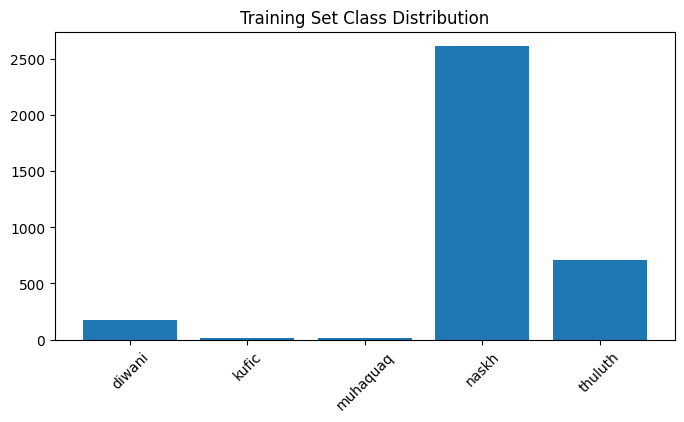


 Computed class weights:
{0: np.float64(4.14), 1: np.float64(39.1), 2: np.float64(63.981818181818184), 3: np.float64(0.269345579793341), 4: np.float64(0.9954738330975955)}

 Class indices comparison:
Train: {'diwani': 0, 'kufic': 1, 'muhaquaq': 2, 'naskh': 3, 'thuluth': 4}
Val:   {'diwani': 0, 'kufic': 1, 'muhaquaq': 2, 'naskh': 3, 'thuluth': 4}
Test:  {'diwani': 0, 'kufic': 1, 'muhaquaq': 2, 'naskh': 3, 'thuluth': 4}

 Class indices are consistent across train/val/test.

 Label map saved successfully at: /content/data/label_map.json


In [ ]:
# =========================================
#  1. Imports
# =========================================
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter

# =========================================
#  2. Paths setup
# =========================================
base_dir = "/content/data"
train_dir = os.path.join(base_dir, "train")

print("📂 Train directory found:", os.path.exists(train_dir))
print("Subfolders (classes):", os.listdir(train_dir))

# =========================================
#  3. Standardize class folder names
# =========================================
# نوحّد الأسماء (lowercase + no spaces)
for folder in os.listdir(train_dir):
    old_path = os.path.join(train_dir, folder)
    new_name = folder.strip().lower().replace(" ", "_")
    new_path = os.path.join(train_dir, new_name)
    if old_path != new_path:
        os.rename(old_path, new_path)

class_names = sorted(os.listdir(train_dir))
print("\n Class names standardized to lowercase:")
print("Class Names:", class_names)

# =========================================
#  4. Split into train/val/test
# =========================================
!pip install split-folders --quiet
import splitfolders

output_split_dir = os.path.join(base_dir, "splitted")

# نحط التقسيم داخل مجلد جديد لتجنب الخطأ السابق
splitfolders.ratio(train_dir, output=output_split_dir, seed=42, ratio=(0.7, 0.15, 0.15))
print("\n Data split into train/val/test folders successfully!")

# =========================================
#  5. Create Generators
# =========================================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_path = os.path.join(output_split_dir, "train")
val_path   = os.path.join(output_split_dir, "val")
test_path  = os.path.join(output_split_dir, "test")

train_gen = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

val_gen = val_datagen.flow_from_directory(
    val_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_gen = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

# =========================================
#  6. Class distribution
# =========================================
train_counts = Counter(train_gen.classes)
df_counts = pd.DataFrame.from_dict(train_counts, orient='index', columns=['count'])
df_counts.index = [k for k, v in sorted(train_gen.class_indices.items(), key=lambda x: x[1])]
print("\n Class distribution in training set:")
print(df_counts)

plt.figure(figsize=(8,4))
plt.bar(df_counts.index, df_counts['count'])
plt.title("Training Set Class Distribution")
plt.xticks(rotation=45)
plt.show()

# =========================================
#  7. Compute class weights (for imbalance)
# =========================================
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weight_dict = dict(enumerate(class_weights))
print("\n Computed class weights:")
print(class_weight_dict)

# =========================================
#  8. Check class_indices consistency
# =========================================
print("\n Class indices comparison:")
print("Train:", train_gen.class_indices)
print("Val:  ", val_gen.class_indices)
print("Test: ", test_gen.class_indices)

if train_gen.class_indices == val_gen.class_indices == test_gen.class_indices:
    print("\n Class indices are consistent across train/val/test.")
else:
    print("\n Class indices mismatch detected! Check folder structure or names.")

# =========================================
#  9. Save label map
# =========================================
label_map_path = os.path.join(base_dir, "label_map.json")
with open(label_map_path, "w") as f:
    json.dump(train_gen.class_indices, f, indent=4)

print(f"\n Label map saved successfully at: {label_map_path}")

In [ ]:
# 1) تأكيد المسارات وعدد الصور في كل جزء
import os
for split in ["train","val","test"]:
    p = f"/content/data/splitted/{split}"
    classes = sorted([d for d in os.listdir(p) if os.path.isdir(os.path.join(p,d))])
    n = sum(len(files) for _,_,files in os.walk(p))
    print(f"{split}: {n} images | classes: {classes}")

# 2) تأكيد ترتيب الفئات المثبّت (ينعكس على label_map.json)
print("class_indices (train):", train_gen.class_indices)

# 3) التأكد من التناسق بين المجموعات
assert train_gen.class_indices == val_gen.class_indices == test_gen.class_indices, "Indices mismatch!"

# 4) عرض الـ class_weights (مختصر)
print("class_weight_dict:", {k: round(float(v),3) for k,v in class_weight_dict.items()})

train: 3519 images | classes: ['diwani', 'kufic', 'muhaquaq', 'naskh', 'thuluth']
val: 753 images | classes: ['diwani', 'kufic', 'muhaquaq', 'naskh', 'thuluth']
test: 759 images | classes: ['diwani', 'kufic', 'muhaquaq', 'naskh', 'thuluth']
class_indices (train): {'diwani': 0, 'kufic': 1, 'muhaquaq': 2, 'naskh': 3, 'thuluth': 4}
class_weight_dict: {0: 4.14, 1: 39.1, 2: 63.982, 3: 0.269, 4: 0.995}


In [ ]:
# ==== Export artifacts for the team/report ====
import json, os
from pathlib import Path
import pandas as pd

BASE_DIR = "/content/data"
SPLIT_DIR = f"{BASE_DIR}/splitted"

# 1) # 1) تأكيد المسارات وعدد الصور في كل جزء
import os
for split in ["train","val","test"]:
    p = f"/content/data/splitted/{split}"
    classes = sorted([d for d in os.listdir(p) if os.path.isdir(os.path.join(p,d))])
    n = sum(len(files) for _,_,files in os.walk(p))
    print(f"{split}: {n} images | classes: {classes}")

# 2) تأكيد ترتيب الفئات المثبّت (ينعكس على label_map.json)
print("class_indices (train):", train_gen.class_indices)

# 3) التأكد من التناسق بين المجموعات
assert train_gen.class_indices == val_gen.class_indices == test_gen.class_indices, "Indices mismatch!"

# 4) عرض الـ class_weights (مختصر)

print("class_weight_dict:", {k: round(float(v),3) for k,v in class_weight_dict.items()})
df_counts.to_csv(f"{BASE_DIR}/train_class_counts.csv", index=True)

# 2) class weights
with open(f"{BASE_DIR}/class_weights.json","w") as f:
    json.dump({int(k): float(v) for k,v in class_weight_dict.items()}, f, indent=2)

# 3) class indices / label map (already saved)
#    path: /content/data/label_map.json

# 4) quick split sizes for report
def count_images(p):
    return sum(len(files) for _,_,files in os.walk(p))
sizes = {
    "train": count_images(f"{SPLIT_DIR}/train"),
    "val":   count_images(f"{SPLIT_DIR}/val"),
    "test":  count_images(f"{SPLIT_DIR}/test"),
}
print("Split sizes:", sizes)

# 5) pin class_names order (hand to training teammate)
pinned_class_names = [k for k,_ in sorted(train_gen.class_indices.items(), key=lambda x: x[1])]
print("Pinned class_names:", pinned_class_names)

print("\nFiles saved:")
print(f"- {BASE_DIR}/label_map.json")
print(f"- {BASE_DIR}/class_weights.json")
print(f"- {BASE_DIR}/train_class_counts.csv")
print(f"- {SPLIT_DIR}/{{train,val,test}}")

train: 3519 images | classes: ['diwani', 'kufic', 'muhaquaq', 'naskh', 'thuluth']
val: 753 images | classes: ['diwani', 'kufic', 'muhaquaq', 'naskh', 'thuluth']
test: 759 images | classes: ['diwani', 'kufic', 'muhaquaq', 'naskh', 'thuluth']
class_indices (train): {'diwani': 0, 'kufic': 1, 'muhaquaq': 2, 'naskh': 3, 'thuluth': 4}
class_weight_dict: {0: 4.14, 1: 39.1, 2: 63.982, 3: 0.269, 4: 0.995}
Split sizes: {'train': 3519, 'val': 753, 'test': 759}
Pinned class_names: ['diwani', 'kufic', 'muhaquaq', 'naskh', 'thuluth']

Files saved:
- /content/data/label_map.json
- /content/data/class_weights.json
- /content/data/train_class_counts.csv
- /content/data/splitted/{train,val,test}


In [ ]:
# =========================
# Stage-1 High-Performance Training (ResNet50 head-only) - TF 2.19 / Keras 3
# =========================
import os, tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.mixed_precision import set_global_policy
import matplotlib.pyplot as plt

print("TF:", tf.__version__)

# -------- 0) إعدادات عامة للأداء --------
set_global_policy("mixed_float16")   # أسرع على أغلب الـGPU
AUTOTUNE  = tf.data.AUTOTUNE
IMG_SIZE  = (224, 224)
BATCH     = 32
NUM_CLASSES = 5
EPOCHS    = 30

train_dir = "/content/data/splitted/train"
val_dir   = "/content/data/splitted/val"

# -------- 1) تحميل البيانات --------
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, image_size=IMG_SIZE, batch_size=BATCH, shuffle=True,  label_mode="int"
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,   image_size=IMG_SIZE, batch_size=BATCH, shuffle=False, label_mode="int"
)

# Augmentation على الـGPU
data_augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
], name="augment")

# تحسينات tf.data (متوافقة مع TF 2.19)
opt = tf.data.Options()
opt.experimental_optimization.map_parallelization = True
opt.experimental_optimization.apply_default_optimizations = True
# (اختياري، إذا حبيتي:)
# opt.experimental_optimization.map_fusion = True
# opt.experimental_optimization.filter_fusion = True
opt.experimental_deterministic = False  # لا حتمي لرفع الـthroughput

def pipeline(ds, training: bool):
    if training:
        ds = ds.map(lambda x, y: (data_augment(x, training=True), y),
                    num_parallel_calls=AUTOTUNE)
        # لو الذاكرة تسمح:
        # ds = ds.cache()
    ds = ds.prefetch(AUTOTUNE)
    ds = ds.with_options(opt)
    return ds

train_ds = pipeline(train_ds, training=True)
val_ds   = pipeline(val_ds,   training=False)

# -------- 2) بناء النموذج (تجميد ResNet50 وتدريب الرأس فقط) --------
base = ResNet50(include_top=False, weights="imagenet", input_shape=IMG_SIZE + (3,))
base.trainable = False

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = tf.keras.applications.resnet50.preprocess_input(inputs)  # preprocess داخل النموذج
x = base(x, training=False)                                  # تثبيت BN
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)  # مهم مع mixed precision
model = models.Model(inputs, outputs, name="ResNet50_Stage1_head_only_fast")

# Optimizer
try:
    from tensorflow.keras.optimizers import AdamW
    optimizer = AdamW(learning_rate=1e-3, weight_decay=1e-4)
except Exception:
    optimizer = optimizers.Adam(learning_rate=1e-3)

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
    jit_compile=True  # XLA
)

model.summary()

# -------- 3) Callbacks --------
ckpt_path = "best_stage1.weights.h5"   # ✅ لازم .weights.h5 مع save_weights_only=True

early_stop = EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1)
model_ckpt = ModelCheckpoint(filepath=ckpt_path, monitor="val_loss",
                             save_best_only=True, save_weights_only=True, verbose=1)
callbacks = [early_stop, reduce_lr, model_ckpt]

# -------- 4) التدريب --------
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks)
print(f"✅ Best Stage-1 weights saved to: {ckpt_path}")

# -------- 5) الرسم --------
def plot_history(hist, title_prefix="Stage-1"):
    h = hist.history

    # Accuracy
    plt.figure()
    plt.plot(h["accuracy"], label="train_acc")
    if "val_accuracy" in h: plt.plot(h["val_accuracy"], label="val_acc")
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy")
    plt.legend(); plt.grid(True); plt.show()

    # Loss
    plt.figure()
    plt.plot(h["loss"], label="train_loss")
    if "val_loss" in h: plt.plot(h["val_loss"], label="val_loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.legend(); plt.grid(True); plt.show()

plot_history(history)

# -------- 6) (اختياري) إعادة تحميل الأوزان المثلى --------
model.load_weights(ckpt_path)
print("Weights reloaded from:", ckpt_path)

TF: 2.19.0
Found 3519 files belonging to 5 classes.
Found 753 files belonging to 5 classes.


Model: "ResNet50_Stage1_head_only_fast"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer_3[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer_3[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 5)         │     10,245 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,597,957 (90.02 MB)

 Trainable params: 10,245 (40.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 530ms/step - accuracy: 0.7631 - loss: 0.7419
Epoch 1: val_loss improved from inf to 0.14042, saving model to best_stage1.weights.h5
110/110 ━━━━━━━━━━━━━━━━━━━━ 89s 658ms/step - accuracy: 0.7641 - loss: 0.7388 - val_accuracy: 0.9588 - val_loss: 0.1404 - learning_rate: 0.0010
Epoch 2/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 539ms/step - accuracy: 0.9479 - loss: 0.1731
Epoch 2: val_loss improved from 0.14042 to 0.12262, saving model to best_stage1.weights.h5
110/110 ━━━━━━━━━━━━━━━━━━━━ 66s 593ms/step - accuracy: 0.9479 - loss: 0.1729 - val_accuracy: 0.9628 - val_loss: 0.1226 - learning_rate: 0.0010
Epoch 3/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step - accuracy: 0.9653 - loss: 0.1188
Epoch 3: val_loss improved from 0.12262 to 0.12241, saving model to best_stage1.weights.h5
110/110 ━━━━━━━━━━━━━━━━━━━━ 58s 520ms/step - accuracy: 0.9653 - loss: 0.1188 - val_accuracy: 0.9562 - val_loss: 0.1224 - learning_rate: 0.0010
Epoch 4/30
110/110 ━━━━━━━━━━━━━━━━

In [ ]:
# =========================
# Stage-2: Fine-Tuning (ResNet50, TF 2.19 / Keras 3)
# يعمل مباشرة بعد كود Stage-1 أعلاه
# =========================
import os, tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# 0) نستخدم history حق Stage-1 للدمج
history1 = history  # ← من كودك السابق

# 1) مسارات الحفظ في نفس المجلد (لا ننشئ مجلد جديد)
OUTPUT_DIR = "."
BEST_FINAL_BEST = os.path.join(OUTPUT_DIR, "best_resnet50_calligraphy.h5")
FINAL_PATH      = os.path.join(OUTPUT_DIR, "resnet50_calligraphy_final.h5")

# 2) تحميل أفضل أوزان Stage-1 (رأس فقط) قبل الفاين-تونينغ
model.load_weights("best_stage1.weights.h5")

# 3) فك آخر ~40 طبقة من الـResNet50 (تقليل خطر الـoverfitting)
for layer in base.layers:
    layer.trainable = False
for layer in base.layers[-40:]:
    layer.trainable = True

# 4) خفض LR = 1e-5 وتثبيت الإعدادات
#    ملاحظة: مع mixed precision خليك تستخدم loss/metrics العادية مثل ما هي
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5)
model.compile(optimizer=optimizer,
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=["accuracy"],
              jit_compile=True)

# 5) كولباكس تقلل الـoverfitting وتضبط الـLR + تحفظ أفضل موديل
cb_stage2 = [
    EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    ModelCheckpoint(BEST_FINAL_BEST, monitor="val_loss",
                    save_best_only=True, save_weights_only=False, verbose=1)  # يحفظ موديل كامل .h5
]
# --- Compute class weights to handle class imbalance ---
from collections import Counter
import numpy as np

# extract all labels from the training dataset
labels = np.concatenate([y.numpy() for _, y in train_ds])
print("Samples per class:", Counter(labels))

# compute class weights automatically
total = len(labels)
counts = Counter(labels)
class_weight = {i: total / (len(counts) * count) for i, count in counts.items()}
print("Computed class weights:", class_weight)

# --- Training (Stage-2 Fine-Tuning) ---
history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=cb_stage2,
    class_weight=class_weight  # ✅ this line applies the weights
)


# 7) حفظ آخر وزن بعد اكتمال التدريب
model.save(FINAL_PATH)  # يحفظ موديل كامل باسم resnet50_calligraphy_final.h5

# 8) منحنيات Stage-2 فقط
plt.figure()
plt.plot(history2.history["loss"], label="train")
plt.plot(history2.history["val_loss"], label="val")
plt.title("Stage-2 Loss"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.savefig("stage2_loss.png", dpi=150); plt.close()

plt.figure()
plt.plot(history2.history["accuracy"], label="train")
plt.plot(history2.history["val_accuracy"], label="val")
plt.title("Stage-2 Accuracy"); plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.savefig("stage2_acc.png", dpi=150); plt.close()

# 9) دمج منحنيات Stage-1 + Stage-2 (علشان العرض والمقارنة)
def merge_histories(h1, h2, key):
    a = h1.history.get(key, []) if h1 is not None else []
    b = h2.history.get(key, []) if h2 is not None else []
    return a + b

merged_loss  = merge_histories(history1, history2, "loss")
merged_vloss = merge_histories(history1, history2, "val_loss")
merged_acc   = merge_histories(history1, history2, "accuracy")
merged_vacc  = merge_histories(history1, history2, "val_accuracy")

plt.figure()
plt.plot(merged_loss,  label="train")
plt.plot(merged_vloss, label="val")
plt.title("Stage-1 + Stage-2 Loss"); plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.savefig("merged_loss.png", dpi=150); plt.close()

plt.figure()
plt.plot(merged_acc,  label="train")
plt.plot(merged_vacc, label="val")
plt.title("Stage-1 + Stage-2 Accuracy"); plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.savefig("merged_acc.png", dpi=150); plt.close()

print("✓ Fine-Tuning done")
print("  best:", BEST_FINAL_BEST)
print("  final:", FINAL_PATH)




Samples per class: Counter({np.int32(3): 2613, np.int32(4): 707, np.int32(0): 170, np.int32(1): 18, np.int32(2): 11})
Computed class weights: {np.int32(3): 0.269345579793341, np.int32(4): 0.9954738330975955, np.int32(0): 4.14, np.int32(2): 63.981818181818184, np.int32(1): 39.1}
Epoch 1/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 599ms/step - accuracy: 0.9333 - loss: 0.8959
Epoch 1: val_loss improved from inf to 0.11463, saving model to ./best_resnet50_calligraphy.h5


110/110 ━━━━━━━━━━━━━━━━━━━━ 113s 756ms/step - accuracy: 0.9333 - loss: 0.8955 - val_accuracy: 0.9641 - val_loss: 0.1146 - learning_rate: 1.0000e-05
Epoch 2/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 519ms/step - accuracy: 0.9472 - loss: 0.3184
Epoch 2: val_loss did not improve from 0.11463
110/110 ━━━━━━━━━━━━━━━━━━━━ 63s 567ms/step - accuracy: 0.9471 - loss: 0.3187 - val_accuracy: 0.9495 - val_loss: 0.1395 - learning_rate: 1.0000e-05
Epoch 3/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 520ms/step - accuracy: 0.9461 - loss: 0.2034
Epoch 3: val_loss did not improve from 0.11463
110/110 ━━━━━━━━━━━━━━━━━━━━ 63s 562ms/step - accuracy: 0.9460 - loss: 0.2035 - val_accuracy: 0.9469 - val_loss: 0.1570 - learning_rate: 1.0000e-05
Epoch 4/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 522ms/step - accuracy: 0.9454 - loss: 0.1376
Epoch 4: val_loss did not improve from 0.11463
110/110 ━━━━━━━━━━━━━━━━━━━━ 63s 569ms/step - accuracy: 0.9454 - loss: 0.1376 - val_accuracy: 0.9482 - val_loss: 0.1557 - learning_rate: 1.0000e-05
Ep

✓ Fine-Tuning done
  best: ./best_resnet50_calligraphy.h5
  final: ./resnet50_calligraphy_final.h5


Found 759 files belonging to 5 classes.
Test Accuracy: 95.78%
              precision    recall  f1-score   support

      diwani      0.867     0.703     0.776        37
       kufic      0.833     1.000     0.909         5
    muhaquaq      0.000     0.000     0.000         4
       naskh      0.987     0.979     0.983       561
     thuluth      0.880     0.967     0.922       152

    accuracy                          0.958       759
   macro avg      0.714     0.730     0.718       759
weighted avg      0.954     0.958     0.955       759



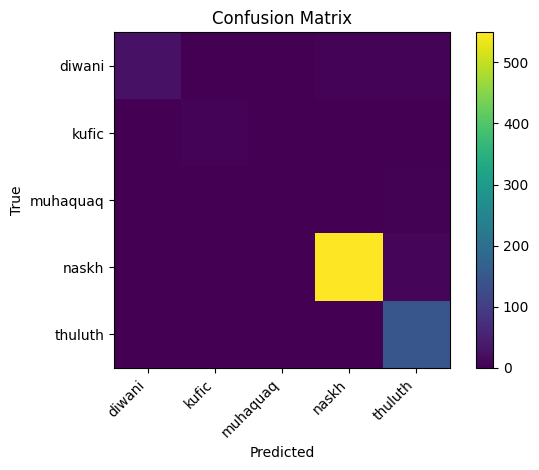

In [ ]:
import os, numpy as np, matplotlib.pyplot as plt, tensorflow as tf
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1) تحميل أفضل نموذج
MODEL_PATH = "best_resnet50_calligraphy.keras"  # أو .h5
model = tf.keras.models.load_model(MODEL_PATH, compile=False)

# 2) تحضير test_ds
test_dir = "/content/data/splitted/test"
IMG_SIZE = (224, 224)

raw_test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir, image_size=IMG_SIZE, batch_size=32, shuffle=False, label_mode="int"
)
class_names = raw_test_ds.class_names            # <-- خذيها قبل prefetch
test_ds = raw_test_ds.prefetch(tf.data.AUTOTUNE) # <-- بعدين سرّعي

# 3) تنبؤ + دقّة
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)
y_pred = model.predict(test_ds, verbose=0).argmax(axis=1)
print(f"Test Accuracy: {accuracy_score(y_true, y_pred)*100:.2f}%")

# 4) تقرير + مصفوفة التباس (بدون تحذير)
print(classification_report(y_true, y_pred, target_names=class_names, digits=3, zero_division=0))
cm = confusion_matrix(y_true, y_pred)

plt.imshow(cm); plt.title("Confusion Matrix"); plt.colorbar()
plt.xticks(range(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(range(len(class_names)), class_names)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout(); plt.show()




Number of misclassified samples: 5


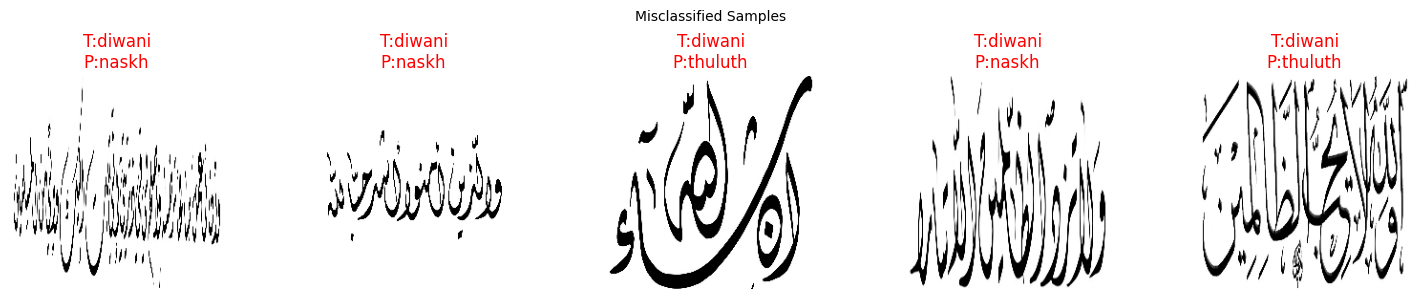

✓ Saved images to folder: misclassified


In [ ]:
import os, numpy as np, matplotlib.pyplot as plt, matplotlib.image as mpimg, shutil

# Save first 5 misclassified samples
mis_idx = np.where(y_true != y_pred)[0][:5]
print(f"Number of misclassified samples: {len(mis_idx)}")

save_dir = "misclassified"
if os.path.exists(save_dir):
    shutil.rmtree(save_dir)
os.makedirs(save_dir, exist_ok=True)

plt.figure(figsize=(15, 3))
for i, idx in enumerate(mis_idx):
    img_ds = test_ds.unbatch().skip(idx).take(1)
    for x, _ in img_ds:
        img = x.numpy().astype("uint8")

        # Display image
        plt.subplot(1, len(mis_idx), i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"T:{class_names[y_true[idx]]}\nP:{class_names[y_pred[idx]]}", color="red")

        # Save image
        fname = f"{i+1:02d}_true-{class_names[y_true[idx]]}_pred-{class_names[y_pred[idx]]}.png"
        mpimg.imsave(os.path.join(save_dir, fname), img)

plt.suptitle("Misclassified Samples", fontsize=10)
plt.tight_layout()
plt.savefig("misclassified_grid.png", dpi=150)
plt.show()

print(f"✓ Saved images to folder: {save_dir}")




In [ ]:
import json
label_map = {i: name for i, name in enumerate(class_names)}
with open("label_map.json", "w", encoding="utf-8") as f:
    json.dump(label_map, f, ensure_ascii=False, indent=2)
print("Saved: label_map.json")


Saved: label_map.json


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(values_format="d", xticks_rotation=45)
plt.show()

In [ ]:
import numpy as np, matplotlib.pyplot as plt

test_generator.reset()
X_batch, y_batch = next(test_generator)
pred = model.predict(X_batch)
y_true = np.argmax(y_batch, axis=1)
y_pred = np.argmax(pred, axis=1)

plt.figure(figsize=(12,8))
for i in range(12):
    plt.subplot(3,4,i+1)
    img = X_batch[i]
    # إذا كنتِ تستخدمين preprocess_input قد تحتاجين عكسها للعرض (اختياري)
    plt.imshow((img - img.min())/(img.max()-img.min()))
    plt.title(f"T:{target_names[y_true[i]]}\nP:{target_names[y_pred[i]]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_out = conv_out[0]
    heatmap = conv_out @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

# مثال سريع على صورة وحدة:
test_generator.reset()
X_batch, _ = next(test_generator)
img = X_batch[0:1]

# اختاري اسم آخر conv layer في ResNet50 غالبًا:
last_conv = "conv5_block3_out"
heatmap = make_gradcam_heatmap(img, model, last_conv)

plt.imshow((img[0]-img[0].min())/(img[0].max()-img[0].min()))
plt.imshow(heatmap, alpha=0.4)
plt.axis("off")
plt.show()

In [ ]:
# unfreeze last 30 layers (مثال)
for layer in base_model.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
lr_cb = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=2, verbose=1
)
callbacks.append(lr_cb)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

y_train = np.argmax(train_generator.labels if hasattr(train_generator, "labels") else train_generator.classes)
classes = np.unique(train_generator.classes)
class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=train_generator.classes)
class_weights = {i:w for i,w in zip(classes, class_weights)}

history = model.fit(
    generator_with_reset(train_generator),
    steps_per_epoch=steps_per_epoch,
    epochs=20,
    validation_data=generator_with_reset(val_generator),
    validation_steps=validation_steps,
    callbacks=callbacks,
    class_weight=class_weights
)

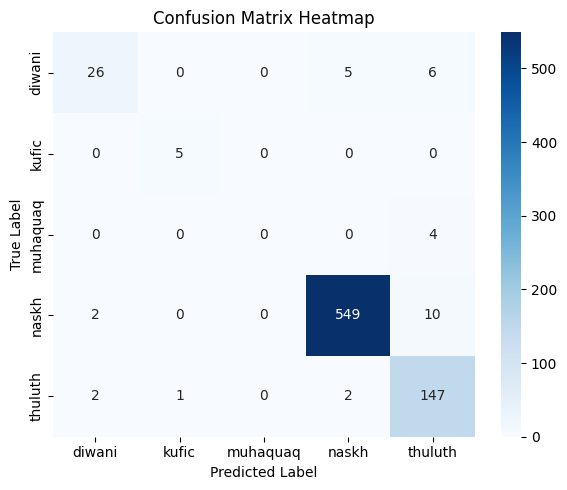

✓ Heatmap saved successfully at: confusion_matrix_heatmap.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)
class_labels = class_names  # from your dataset

# Plot and save heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

# Save the figure
save_path = "confusion_matrix_heatmap.png"
plt.savefig(save_path, dpi=150)
plt.show()

print(f"✓ Heatmap saved successfully at: {save_path}")


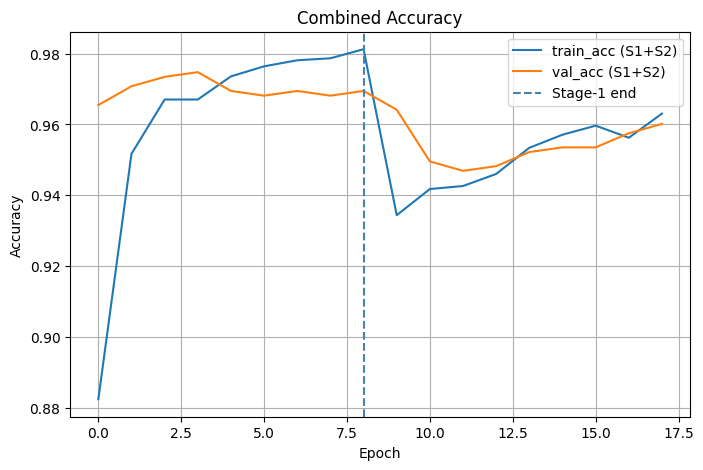

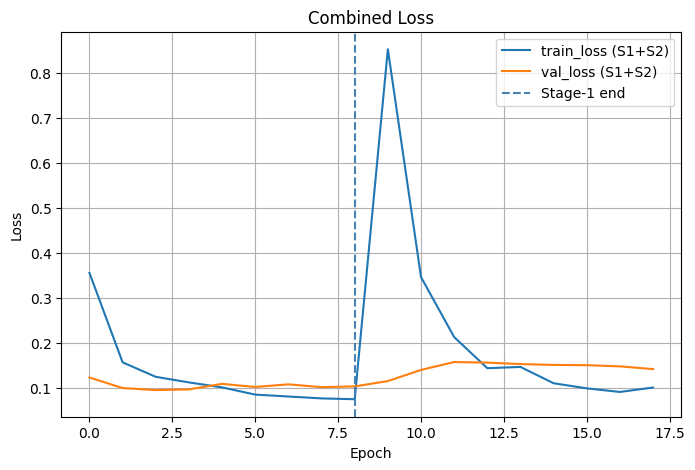

In [ ]:
# =========================
# Combined Stage-1 + Stage-2 Graphs (مع فاصل واضح)
# =========================
import matplotlib.pyplot as plt

def merge_histories(h1, h2, key):
    a = h1.history.get(key, []) if h1 is not None else []
    b = h2.history.get(key, []) if h2 is not None else []
    return a + b

# ندمج بيانات المرحلتين
merged_loss  = merge_histories(history1, history2, "loss")
merged_vloss = merge_histories(history1, history2, "val_loss")
merged_acc   = merge_histories(history1, history2, "accuracy")
merged_vacc  = merge_histories(history1, history2, "val_accuracy")

# طول المرحلة الأولى لتحديد مكان الخط الفاصل
stage1_len = len(history1.history["loss"]) if history1 is not None else 0

# ------------------- الرسم -------------------

# Accuracy
plt.figure(figsize=(8,5))
plt.plot(merged_acc,  label="train_acc (S1+S2)")
plt.plot(merged_vacc, label="val_acc (S1+S2)")
if stage1_len > 0:
    plt.axvline(x=stage1_len - 1, color="steelblue", linestyle="--", label="Stage-1 end")
plt.title("Combined Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(8,5))
plt.plot(merged_loss,  label="train_loss (S1+S2)")
plt.plot(merged_vloss, label="val_loss (S1+S2)")
if stage1_len > 0:
    plt.axvline(x=stage1_len - 1, color="steelblue", linestyle="--", label="Stage-1 end")
plt.title("Combined Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

